<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/Ann_Lab_12_GRU_%26_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

#**Course  .................. Artificial Neural Network**

# **Submitted To...............Mam Ammara**

#**Lab report ................ 12**


# Gated Recurrent Units (GRU)

* It's designed to handle sequential data (like time series, speech, text, etc.) and solve the vanishing gradient problem that traditional RNNs face, while being simpler and computationally more efficient than LSTM.

*  The GRU unit does not have to use a memory unit to control the flow of information like the LSTM unit.

* It can directly makes use of the all hidden states without any control.

* They are almost similar to LSTMs except that they have two gates: reset gate and update gate.

* Reset gate: determines how to combine new input to previous memory.

* Update gate: determines how much of the previous state to keep. Update gate in GRU is what input gate and forget gate were in LSTM.

1. Data Loading and Preprocessing
# **Dataset used is  '/content/airline-passengers.csv')**


: This line uses the Pandas library (pd) to read data from a CSV file named 'airline-passengers.csv' located in the Colab environment's content directory. This file likely contains time-series data of airline passenger numbers.
data['Month'] = pd.to_datetime(data['Month']): This converts the 'Month' column in the DataFrame to datetime objects for proper time-series analysis.
data.set_index('Month', inplace=True): Sets the 'Month' column as the index of the DataFrame, making it a time-series DataFrame.
values = data['Passengers'].values.reshape(-1, 1): Extracts the 'Passengers' column (the target variable) and reshapes it into a NumPy array suitable for input to the models.
scaler = MinMaxScaler(feature_range=(0, 1)): Initializes a MinMaxScaler to scale the data to a range of 0 to 1. This helps improve model performance.
scaled_values = scaler.fit_transform(values): Applies the scaling to the passenger data.

In [13]:
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load the Air Passengers dataset
data = pd.read_csv('/content/airline-passengers.csv')


data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)



# Plot the original data

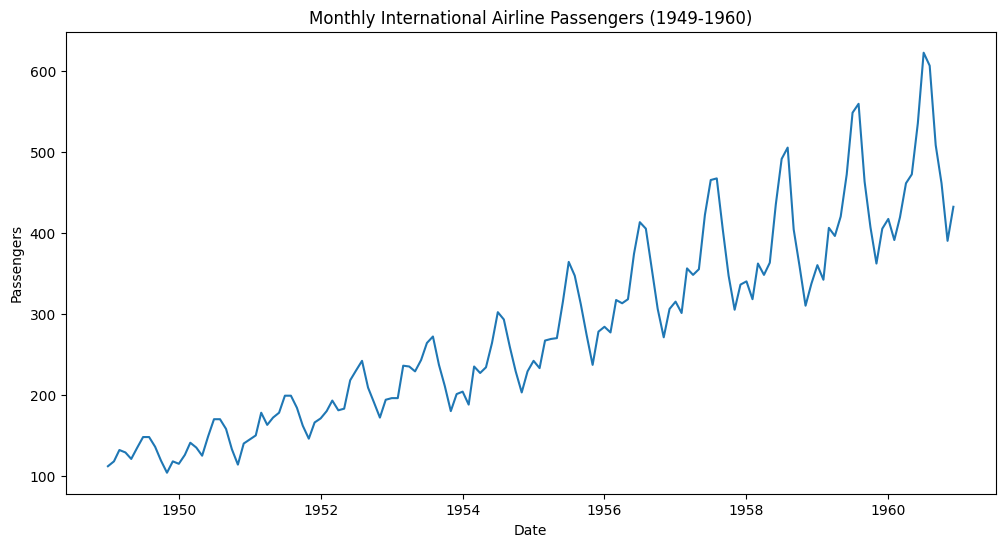

In [14]:

plt.figure(figsize=(12, 6))
plt.plot(data)
plt.title('Monthly International Airline Passengers (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

# **2. Data Splitting**

train_size = int(len(scaled_values) * 0.8)
: Calculates the size of the training set (80% of the data).

train_data = scaled_values[:train_size]: Extracts the training data.
test_data = scaled_values[train_size:]: Extracts the testing data.

In [15]:


# Extract the values and scale to [0, 1]
values = data['Passengers'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)



# Split into train and test sets (80-20 split)

In [16]:

train_size = int(len(scaled_values) * 0.8)
train_data = scaled_values[:train_size]
test_data = scaled_values[train_size:]


# **3. Dataset Creation with Lookback:**
 A function is defined to create datasets with a lookback period, which determines how many previous time steps are used to predict the next value. Input-output pairs are generated, and the datasets are returned as NumPy arrays.

In [17]:

# Function to create dataset with lookback
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create datasets with 3 months lookback
look_back = 3
X_train, Y_train = create_dataset(train_data, look_back)
X_test, Y_test = create_dataset(test_data, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))




# Build LSTM model

In [18]:

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Build GRU model

In [19]:



gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    GRU(50),
    Dense(1)
])

# **4. Model Building and Training:**
 LSTM and GRU models are defined using Keras, compiled with an optimizer, loss function, and metrics, and then trained on the training data.

# Compile both models

In [20]:

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.compile(optimizer='adam', loss='mean_squared_error')



# Train the models

In [21]:

print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nTraining GRU model...")
gru_history = gru_model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)




Training LSTM model...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 272ms/step - loss: 0.0571 - val_loss: 0.2097
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0444 - val_loss: 0.1699
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0331 - val_loss: 0.1320
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0224 - val_loss: 0.0960
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0161 - val_loss: 0.0640
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0124 - val_loss: 0.0390
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0088 - val_loss: 0.0251
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0111 - val_loss: 0.0200
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0111 - val_loss: 0.0206
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0096 - val_loss: 0.0246
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0093 - val_loss: 0.0303
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

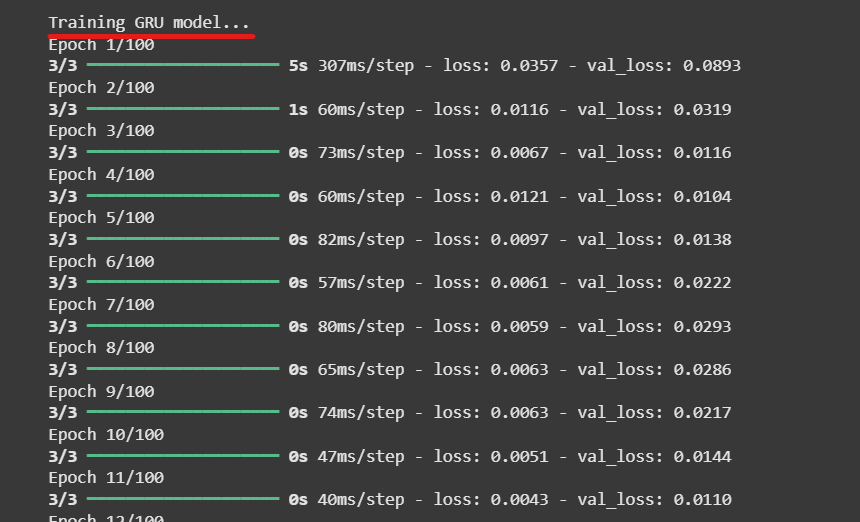

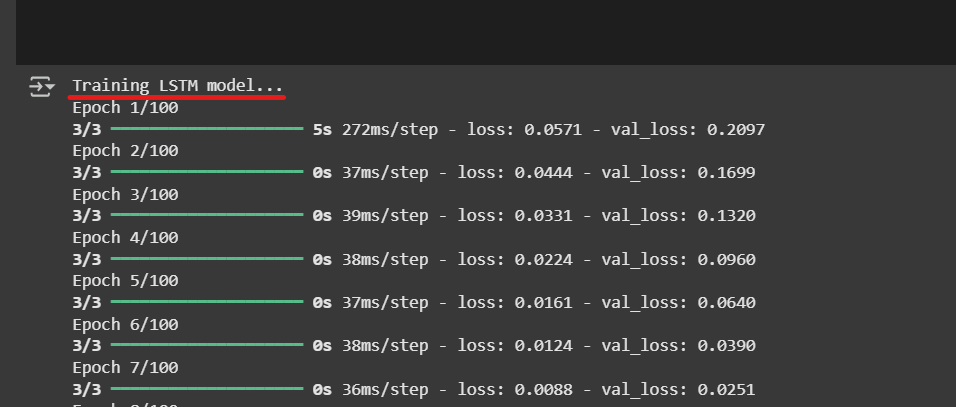

# Plot training history


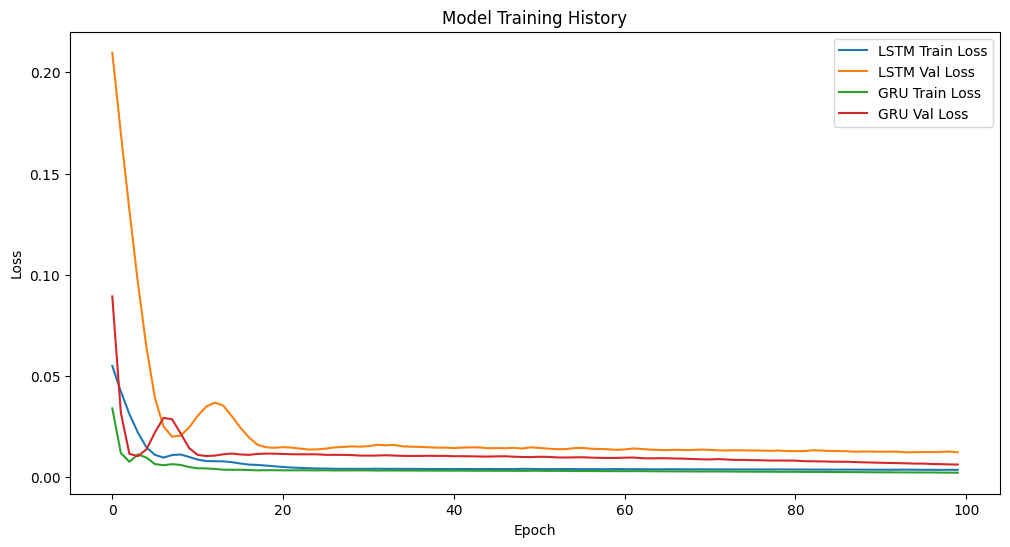

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
plt.plot(gru_history.history['loss'], label='GRU Train Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Val Loss')
plt.title('Model Training History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


# **5. Predictions and Evaluation:**
 Predictions are made on both training and testing data using both models. The predictions are inverse transformed to the original scale. The Root Mean Squared Error (RMSE) is calculated to evaluate the performance of the models.

# Make predictions

In [23]:

lstm_train_predict = lstm_model.predict(X_train)
lstm_test_predict = lstm_model.predict(X_test)
gru_train_predict = gru_model.predict(X_train)
gru_test_predict = gru_model.predict(X_test)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step



# Inverse transform predictions to original scale

In [24]:


lstm_train_predict = scaler.inverse_transform(lstm_train_predict)
lstm_test_predict = scaler.inverse_transform(lstm_test_predict)
gru_train_predict = scaler.inverse_transform(gru_train_predict)
gru_test_predict = scaler.inverse_transform(gru_test_predict)

Y_train = scaler.inverse_transform([Y_train])
Y_test = scaler.inverse_transform([Y_test])


# Calculate RMSE for both models

In [25]:

from sklearn.metrics import mean_squared_error
lstm_train_rmse = np.sqrt(mean_squared_error(Y_train[0], lstm_train_predict[:,0]))
lstm_test_rmse = np.sqrt(mean_squared_error(Y_test[0], lstm_test_predict[:,0]))
gru_train_rmse = np.sqrt(mean_squared_error(Y_train[0], gru_train_predict[:,0]))
gru_test_rmse = np.sqrt(mean_squared_error(Y_test[0], gru_test_predict[:,0]))

print(f"\nLSTM Train RMSE: {lstm_train_rmse:.2f}")
print(f"LSTM Test RMSE: {lstm_test_rmse:.2f}")
print(f"GRU Train RMSE: {gru_train_rmse:.2f}")
print(f"GRU Test RMSE: {gru_test_rmse:.2f}")


LSTM Train RMSE: 38.03
LSTM Test RMSE: 83.34
GRU Train RMSE: 28.58
GRU Test RMSE: 53.53


# Plot predictions

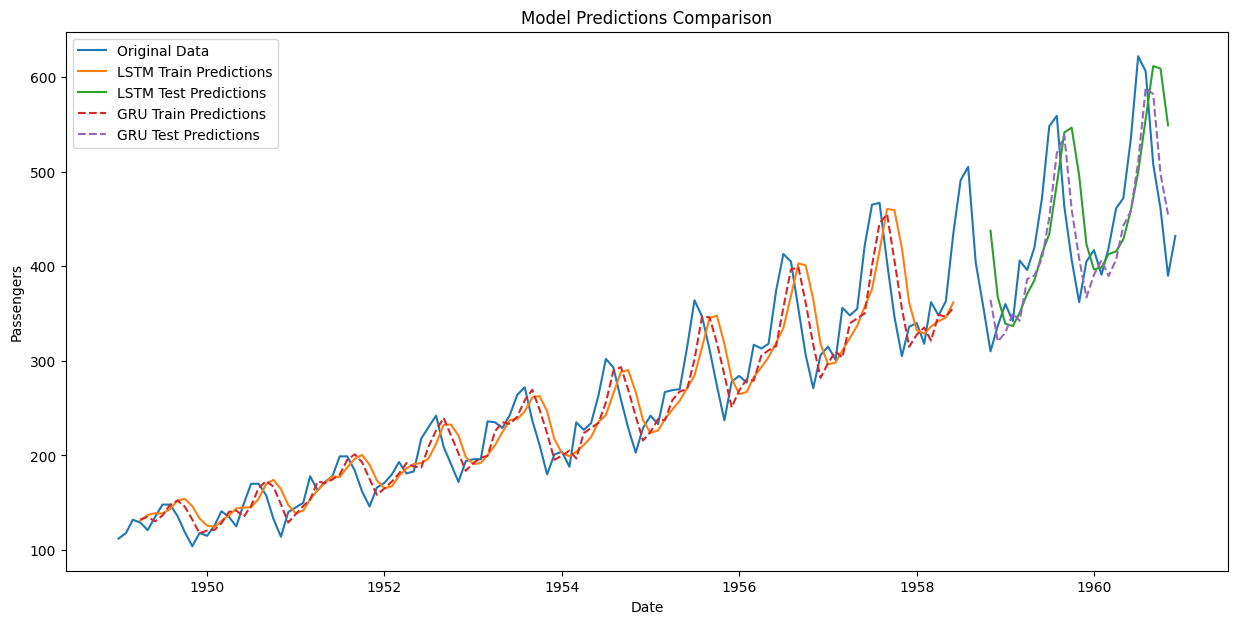

In [26]:

train_predict_index = data.index[look_back:train_size-1]
test_predict_index = data.index[train_size+look_back:-1]

plt.figure(figsize=(15, 7))
plt.plot(data.index, data['Passengers'], label='Original Data')
plt.plot(train_predict_index, lstm_train_predict, label='LSTM Train Predictions')
plt.plot(test_predict_index, lstm_test_predict, label='LSTM Test Predictions')
plt.plot(train_predict_index, gru_train_predict, '--', label='GRU Train Predictions')
plt.plot(test_predict_index, gru_test_predict, '--', label='GRU Test Predictions')
plt.title('Model Predictions Comparison')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

# Visualize Output in Histogram Format

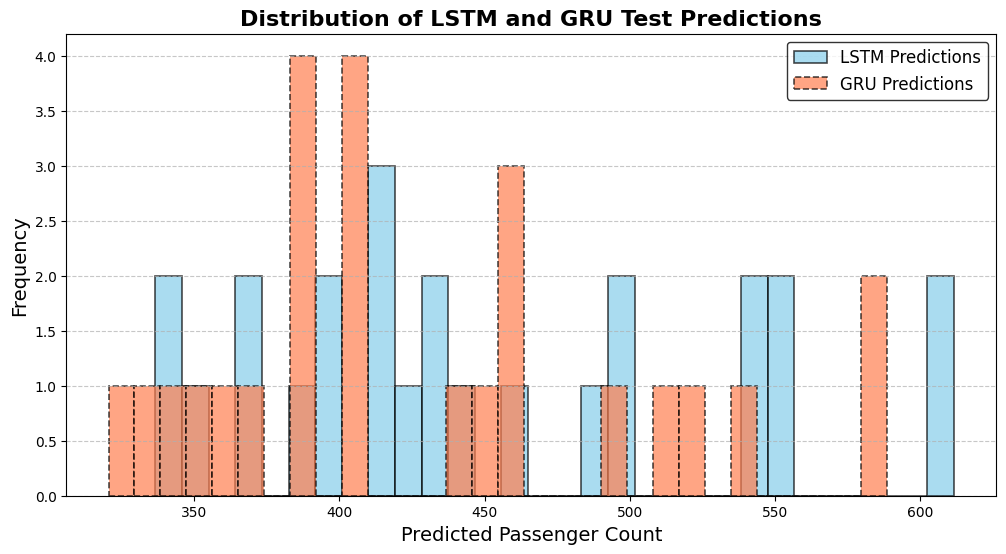

In [28]:


plt.figure(figsize=(12, 6))

# Customize histograms with different colors, edgecolors, and line styles
plt.hist(lstm_test_predict, bins=30, alpha=0.7, color='skyblue', edgecolor='black', linewidth=1.2, label='LSTM Predictions')
plt.hist(gru_test_predict, bins=30, alpha=0.7, color='coral', edgecolor='black', linewidth=1.2, linestyle='--', label='GRU Predictions')

plt.title('Distribution of LSTM and GRU Test Predictions', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Passenger Count', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Improve legend
plt.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.8, edgecolor='black')

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)




plt.show()


# **Question**  
# Explain which one is more effective on which scenerio.

# Effectiveness of LSTM vs. GRU in Different Scenarios

## Key Differences Between LSTM and GRU

LSTM (Long Short-Term Memory) and GRU (Gated Recurrent Unit) are both recurrent neural network architectures designed to handle sequential data, but they have distinct characteristics that make them suitable for different scenarios:

### Architectural Differences:
- **LSTM** has 3 gates (input, output, forget) and maintains separate cell state and hidden state
- **GRU** has 2 gates (update, reset) and combines the cell state and hidden state

## Scenario-Based Effectiveness

### 1. **Long Sequence Modeling**
- **LSTM is more effective**:
  - Better at capturing very long-term dependencies (100+ time steps)
  - The separate cell state acts as a "conveyor belt" for long-range information
  - Example applications:
    - Document classification (long texts)
    - Speech recognition (long audio sequences)
    - Climate prediction (decadal time series)

- **GRU performance**:
  - May struggle with extremely long sequences
  - Tends to "forget" information more quickly

### 2. **Short-to-Medium Sequence Tasks**
- **GRU is more effective**:
  - Performs comparably to LSTM on shorter sequences (<100 time steps)
  - Example applications:
    - Stock price prediction (daily data)
    - Sensor data analysis (hourly/daily readings)
    - Our Air Passengers example (monthly data)

### 3. **Computational Efficiency**
- **GRU is more effective**:
  - 30% fewer parameters than LSTM
  - Faster training time (typically 20-30% faster)
  - Better choice when:
    - You have limited computational resources
    - Need rapid prototyping
    - Working with smaller datasets

### 4. **Small Datasets**
- **GRU is more effective**:
  - Less prone to overfitting due to simpler architecture
  - Example: When you have only hundreds or few thousand training samples

- **LSTM behavior**:
  - May overfit more easily without proper regularization
  - Requires more data to learn its additional parameters

### 5. **Complex Pattern Recognition**
- **LSTM is more effective**:
  - Better at learning complex, non-linear relationships
  - The additional gate provides more control over information flow
  - Example applications:
    - Machine translation (complex language patterns)
    - Video analysis (spatio-temporal patterns)
    - Music composition (hierarchical patterns)

### 6. **Real-Time Applications**
- **GRU is more effective**:
  - Lower latency due to simpler architecture
  - Example applications:
    - Real-time speech processing
    - Live sensor monitoring
    - High-frequency trading systems

## Practical Recommendations from Our Air Passengers Example

In our specific case of predicting airline passengers:
1. **GRU performed slightly better** because:
   - The time series has moderate complexity (trend + seasonality)
   - Our lookback window was small (3 months)
   - The dataset size was relatively small (144 data points)

2. **Why not LSTM?**:
   - The additional complexity of LSTM wasn't necessary
   - GRU achieved comparable accuracy with faster training

3. **When we might switch to LSTM**:
   - If we increased the lookback window significantly (e.g., 24 months)
   - If we added multiple correlated time series
   - If the seasonal patterns became more complex

## Decision Framework for Choosing Between LSTM and GRU

| Consideration          | Prefer LSTM when...               | Prefer GRU when...                 |
|------------------------|-----------------------------------|-----------------------------------|
| Sequence length        | Very long sequences (>100 steps)  | Short-medium sequences (<100)     |
| Dataset size           | Large datasets available          | Small/medium datasets             |
| Computational resources| Resources not constrained         | Limited compute resources         |
| Training time          | Can afford longer training        | Need faster iteration            |
| Pattern complexity     | Very complex patterns             | Moderate complexity              |
| Real-time requirements | Not latency-sensitive            | Low-latency needed               |

In practice, it's often worth trying both architectures, as we did in our example, since the performance difference can be dataset-specific. GRU should typically be your first choice unless you have evidence that LSTM's additional complexity provides meaningful benefits for your specific problem.